# 07 - Forecasting Export Opportunity Demand

This notebook covers the forecasting part of the project **Forecasting and Identifying Global Export Opportunities for Algerian Exporters**. It uses the engineered `data/master_df.parquet` dataset and does not rebuild raw BACI data.

Forecasting means estimating future destination-market demand for selected country-product pairs. In this project, the forecast is used as one input for export opportunity analysis and later for the dashboard.

## Why Forecast `partner_import_v`?

`partner_import_v` is the main target because it represents how much a destination country imports of a specific HS6 product. This is a demand-side signal: a market can be interesting for Algerian exporters even if Algeria has little or no current export presence there.

`alg_export_v` is kept as historical context. It helps show whether Algeria is already present in a market, but it is not the main demand forecast target.

## Non-Hydrocarbon Forecasting Scope

Algeria is already heavily dependent on hydrocarbons. If the forecasting sample is selected only by the largest global or partner import values, products such as HS 270900 petroleum oils dominate the results. That makes the project look like a hydrocarbon forecasting project instead of an export diversification project.

For the default project view, obvious hydrocarbon products are excluded:

- HS codes starting with `27`.
- Product descriptions containing terms such as petroleum, oils, gas, coal, or bituminous.

The code still supports `INCLUDE_HYDROCARBONS = True` when a full all-products view is needed.

## Balanced Country-Product Sample

Instead of selecting only the top country-product pairs globally, the pipeline first selects top products and then selects top countries within each product. This prevents one product from dominating the forecasting sample and gives a more useful panel for diversification analysis.

Default configuration:

- `TOP_PRODUCTS = 50`
- `TOP_COUNTRIES_PER_PRODUCT = 10`
- `FORECAST_HORIZON = 3`
- `INCLUDE_HYDROCARBONS = False`

## Time-Based Split

Forecasting must respect time order. A random split would let future observations influence training and would make the evaluation too optimistic. This notebook uses the existing `split` column when available: `train` and `val` are used for fitting, and `test` is used for final evaluation. In this dataset, the test period is 2022-2023.

## Models and Metrics

The pipeline compares baseline and machine learning models:

- Naive baseline: next value equals the last observed value.
- Moving average baseline: next value equals the recent three-year average.
- Trend-adjusted naive: last value adjusted by a clipped recent growth rate.
- Simple exponential smoothing when enough history exists.
- ARIMA if `statsmodels` is installed; otherwise skipped safely.
- Random Forest, Gradient Boosting, and HistGradientBoosting regressors using lag features.

Baselines are included because advanced models should be compared against simple, transparent forecasting rules.

Metrics include MAE, RMSE, MAPE, sMAPE, and WMAPE. MAPE is kept for familiarity, but it can be unstable when actual trade values are zero or very small. sMAPE and WMAPE are more useful safeguards for this type of trade data.

In [1]:
from pathlib import Path
import importlib
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import forecasting_pipeline
forecasting_pipeline = importlib.reload(forecasting_pipeline)

MASTER_PATH = forecasting_pipeline.MASTER_PATH
OUTPUT_DIR = forecasting_pipeline.OUTPUT_DIR
run_forecasting = forecasting_pipeline.run_forecasting
build_forecast_opportunity_ranking = forecasting_pipeline.build_forecast_opportunity_ranking

TOP_PRODUCTS = 50
TOP_COUNTRIES_PER_PRODUCT = 10
FORECAST_HORIZON = 3
INCLUDE_HYDROCARBONS = False

print("Project root:", PROJECT_ROOT)
print("Pipeline module:", forecasting_pipeline.__file__)
print("Master dataset:", MASTER_PATH)
print("Output directory:", OUTPUT_DIR)

Project root: c:\Users\dey store\Documents\ml-project\machine-learning-project
Pipeline module: c:\Users\dey store\Documents\ml-project\machine-learning-project\forecasting_pipeline.py
Master dataset: C:\Users\dey store\Documents\ml-project\machine-learning-project\data\master_df.parquet
Output directory: C:\Users\dey store\Documents\ml-project\machine-learning-project\data\forecast_outputs


## Run Forecasting Pipeline

In [2]:
results = run_forecasting(
    top_products=TOP_PRODUCTS,
    top_countries_per_product=TOP_COUNTRIES_PER_PRODUCT,
    forecast_horizon=FORECAST_HORIZON,
    include_hydrocarbons=INCLUDE_HYDROCARBONS,
)

metrics = results.metrics
comparison = results.comparison
final_forecasts = results.final_forecasts
top_opportunities = results.top_opportunities
selection_summary = results.selection_summary

Forecasting completed.
Hydrocarbons included: False
Forecast scope: non_hydrocarbon_diversification
Selected countries: 49
Selected products: 50
Selected country-product series: 500
Top selected products:
     k                                            description_short  partner_import_v
710812       Metals: gold, non-monetary, unwrought (but not powder)      3.494921e+09
854231 Electronic integrated circuits: processors and controllers,       2.493622e+09
854239   Electronic integrated circuits: n.e.c. in heading no. 8542      2.342659e+09
870323 Vehicles: spark-ignition internal combustion reciprocating p      2.235361e+09
300490 Medicaments: consisting of mixed or unmixed products n.e.c.       2.160362e+09
851712 Telephones for cellular networks or for other wireless netwo      2.063537e+09
854232                     Electronic integrated circuits: memories      1.525116e+09
260111                 Iron ores and concentrates: non-agglomerated      1.351814e+09
847130 Automatic data

In [3]:
print("Hydrocarbons included:", selection_summary["include_hydrocarbons"])
print("Forecast scope:", selection_summary["forecast_scope"])
print("Selected products:", selection_summary["selected_products"])
print("Selected countries:", selection_summary["selected_countries"])
print("Selected country-product series:", selection_summary["selected_series"])
selection_summary["top_selected_products"]

Hydrocarbons included: False
Forecast scope: non_hydrocarbon_diversification
Selected products: 50
Selected countries: 49
Selected country-product series: 500


,k,description_short,partner_import_v
0,710812,"Metals: gold, non-monetary, unwrought (but not...",3.494921e+09
1,854231,Electronic integrated circuits: processors and...,2.493622e+09
2,854239,Electronic integrated circuits: n.e.c. in head...,2.342659e+09
3,870323,Vehicles: spark-ignition internal combustion r...,2.235361e+09
4,300490,Medicaments: consisting of mixed or unmixed pr...,2.160362e+09
5,851712,Telephones for cellular networks or for other ...,2.063537e+09
6,854232,Electronic integrated circuits: memories,1.525116e+09
7,260111,Iron ores and concentrates: non-agglomerated,1.351814e+09
8,847130,"Automatic data processing machines: portable, ...",1.264958e+09
9,300210,"Blood, human or animal, antisera, other blood ...",1.219421e+09


## Model Performance

In [4]:
metrics

,model,MAE,RMSE,MAPE,sMAPE,WMAPE,notes,selected_for_future_forecast
0,random_forest,1.357026e+06,2.928567e+06,39.105388,19.538785,15.193298,,True
1,naive_last_value,1.646345e+06,3.496631e+06,37.104668,21.857036,18.432524,,False
2,gradient_boosting,1.425660e+06,3.515636e+06,39.315187,18.903928,15.961726,,False
3,simple_exponential_smoothing,1.869218e+06,3.847931e+06,54.843202,25.026230,20.927816,,False
4,hist_gradient_boosting,1.599385e+06,3.854649e+06,45.483576,20.282776,17.906752,,False
5,moving_average_3,2.057219e+06,4.266794e+06,53.715896,26.965841,23.032675,,False
6,trend_adjusted_naive,2.078237e+06,5.105499e+06,40.341775,25.031785,23.267996,,False
7,arima_110_log,NaN,NaN,NaN,NaN,NaN,statsmodels is not installed; ARIMA/SARIMAX sk...,False


## Future Forecast Strategy

The best model is selected by RMSE on the time-based test set. If a flat baseline wins, the pipeline does not blindly use a flat forecast for growth analysis. Instead, it uses a documented trend-aware option, `trend_adjusted_naive`, which adjusts the last observed value by a clipped recent growth rate.

This does not invent growth. It only allows recent observed direction to affect the forecast while limiting extreme growth rates. In the current regenerated run, Random Forest is the best model by RMSE and is also used for future forecasts.

In [5]:
best_row = metrics.dropna(subset=["RMSE"]).sort_values("RMSE").iloc[0]
future_models = metrics.loc[metrics["selected_for_future_forecast"], "model"].tolist()
print(f"Best model by RMSE: {best_row['model']}")
print("Future forecast model/strategy:", future_models)
print(best_row)

Best model by RMSE: random_forest
Future forecast model/strategy: ['random_forest']
model                            random_forest
MAE                             1357025.969532
RMSE                            2928566.672289
MAPE                                 39.105388
sMAPE                                19.538785
WMAPE                                15.193298
notes                                         
selected_for_future_forecast              True
Name: 0, dtype: object


## Dashboard Outputs

The following files are regenerated for the next dashboard step:

- `data/forecast_outputs/final_forecasts.csv`
- `data/forecast_outputs/forecast_model_metrics.csv`
- `data/forecast_outputs/historical_forecast_comparison.csv`
- `data/forecast_outputs/top_forecasted_opportunities.csv`
- `data/forecast_outputs/priority_countries.csv`
- `data/forecast_outputs/priority_products.csv`

`top_forecasted_opportunities.csv` is now the forecast-based ranking file. It uses only columns available in `final_forecasts.csv`; clustering and classification outputs are not required.

In [6]:
final_forecasts.head()

,year,t,country_name,iso3,j,k,description_short,historical_partner_import_v,forecast_partner_import_v,latest_alg_export_v,market_penetration,rca,global_demand_rank,predicted_growth_abs,predicted_growth_pct,forecast_horizon,model,is_hydrocarbon,forecast_scope,series_id
0,2024,2024,Bulgaria,BGR,100,260300,Copper ores and concentrates,1976886.090,2.088071e+06,0.0,0.0,3.156534e-07,0.994900,1.111851e+05,5.624255,1,random_forest,False,non_hydrocarbon_diversification,100__260300
1,2025,2025,Bulgaria,BGR,100,260300,Copper ores and concentrates,1976886.090,2.389721e+06,0.0,0.0,3.156534e-07,0.994900,4.128348e+05,20.883087,2,random_forest,False,non_hydrocarbon_diversification,100__260300
2,2026,2026,Bulgaria,BGR,100,260300,Copper ores and concentrates,1976886.090,2.536784e+06,0.0,0.0,3.156534e-07,0.994900,5.598974e+05,28.322189,3,random_forest,False,non_hydrocarbon_diversification,100__260300
3,2024,2024,Cambodia,KHM,116,710813,"Metals: gold, semi-manufactured",843129.805,2.197433e+06,0.0,0.0,8.472154e-03,0.996055,1.354303e+06,160.628112,1,random_forest,False,non_hydrocarbon_diversification,116__710813
4,2025,2025,Cambodia,KHM,116,710813,"Metals: gold, semi-manufactured",843129.805,2.569900e+06,0.0,0.0,8.472154e-03,0.996055,1.726770e+06,204.804771,2,random_forest,False,non_hydrocarbon_diversification,116__710813


In [7]:
top_opportunities.head(20)

,rank,year,forecast_horizon,country_name,iso3,j,k,description_short,forecasted_value,latest_historical_demand,...,predicted_growth_pct,global_demand_rank,rca,market_penetration,low_market_penetration_score,forecast_opportunity_score,model_used,is_hydrocarbon,forecast_scope,reason_or_interpretation
407,1,2026,3,Germany,DEU,276,870390,Vehicles: for transport of persons (other than...,5.278786e+07,2.966757e+07,...,77.931197,0.998749,NaN,0.0,1.0,0.849578,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, positive predicted gro..."
1472,2,2026,3,USA,USA,842,870390,Vehicles: for transport of persons (other than...,6.184555e+07,4.551074e+07,...,35.892211,0.998749,NaN,0.0,1.0,0.826309,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, positive predicted gro..."
1343,3,2026,3,United Kingdom,GBR,826,870390,Vehicles: for transport of persons (other than...,4.810332e+07,2.637688e+07,...,82.369263,0.998749,NaN,0.0,1.0,0.822836,random_forest,False,non_hydrocarbon_diversification,"Positive predicted growth, strong global deman..."
1153,4,2025,2,Switzerland,CHE,757,710812,"Metals: gold, non-monetary, unwrought (but not...",1.086262e+08,1.004917e+08,...,8.094716,0.999519,NaN,0.0,1.0,0.813805,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
1154,5,2026,3,Switzerland,CHE,757,710812,"Metals: gold, non-monetary, unwrought (but not...",1.086262e+08,1.004917e+08,...,8.094716,0.999519,NaN,0.0,1.0,0.813805,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
1152,6,2024,1,Switzerland,CHE,757,710812,"Metals: gold, non-monetary, unwrought (but not...",1.072937e+08,1.004917e+08,...,6.768687,0.999519,NaN,0.0,1.0,0.810889,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
101,7,2026,3,China,CHN,156,710812,"Metals: gold, non-monetary, unwrought (but not...",7.058077e+07,6.703906e+07,...,5.283051,0.999519,NaN,0.0,1.0,0.807622,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
100,8,2025,2,China,CHN,156,710812,"Metals: gold, non-monetary, unwrought (but not...",7.033307e+07,6.703906e+07,...,4.913565,0.999519,NaN,0.0,1.0,0.806796,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
1213,9,2025,2,United Arab Emirates,ARE,784,710812,"Metals: gold, non-monetary, unwrought (but not...",7.077430e+07,6.767793e+07,...,4.575158,0.999519,NaN,0.0,1.0,0.806066,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
1214,10,2026,3,United Arab Emirates,ARE,784,710812,"Metals: gold, non-monetary, unwrought (but not...",7.067758e+07,6.767793e+07,...,4.432236,0.999519,NaN,0.0,1.0,0.805751,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."


## Forecast-Based Opportunity Ranking

A forecast alone tells us expected future demand, but the dashboard needs a ranked list of opportunities. The opportunity score combines forecasted demand, growth, global demand strength, Algeria's RCA signal, and low current Algerian market penetration.

Default formula:

`forecast_opportunity_score = 0.40 * normalized_forecasted_demand + 0.25 * normalized_predicted_growth_rate + 0.20 * normalized_global_demand_rank + 0.10 * normalized_rca + 0.05 * normalized_low_market_penetration_score`

If an optional component is missing, the available weights are redistributed. Missing values inside available components are treated neutrally, not fabricated as strong or weak signals. Scores are clipped between 0 and 1.

### Score Components

- `normalized_forecasted_demand`: higher when the forecasted partner import value is larger.
- `normalized_predicted_growth_rate`: higher when predicted growth is stronger; extreme growth percentages are clipped before scaling.
- `normalized_global_demand_rank`: higher when the product has stronger global demand.
- `normalized_rca`: higher when Algeria has a stronger revealed comparative advantage signal.
- `low_market_penetration_score`: higher when Algeria's current market penetration is lower, because low penetration can indicate room to grow.

A high score should be interpreted as a promising demand-side opportunity, not a guarantee of export success. Final business decisions still need tariff, logistics, quality, regulation, and firm-level feasibility checks.

In [8]:
ranking, priority_countries, priority_products, scoring_formula = build_forecast_opportunity_ranking(
    OUTPUT_DIR / "final_forecasts.csv",
    output_dir=OUTPUT_DIR,
)

print("Ranked opportunities:", len(ranking))
print("Scoring formula used:", scoring_formula)
ranking.head(10)

Ranked opportunities: 1500
Scoring formula used: 0.400*normalized_forecasted_demand + 0.250*normalized_predicted_growth_rate + 0.200*normalized_global_demand_rank + 0.100*normalized_rca + 0.050*low_market_penetration_score


,rank,year,forecast_horizon,country_name,iso3,j,k,description_short,forecasted_value,latest_historical_demand,...,predicted_growth_pct,global_demand_rank,rca,market_penetration,low_market_penetration_score,forecast_opportunity_score,model_used,is_hydrocarbon,forecast_scope,reason_or_interpretation
407,1,2026,3,Germany,DEU,276,870390,Vehicles: for transport of persons (other than...,5.278786e+07,2.966757e+07,...,77.931197,0.998749,NaN,0.0,1.0,0.849578,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, positive predicted gro..."
1472,2,2026,3,USA,USA,842,870390,Vehicles: for transport of persons (other than...,6.184555e+07,4.551074e+07,...,35.892211,0.998749,NaN,0.0,1.0,0.826309,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, positive predicted gro..."
1343,3,2026,3,United Kingdom,GBR,826,870390,Vehicles: for transport of persons (other than...,4.810332e+07,2.637688e+07,...,82.369263,0.998749,NaN,0.0,1.0,0.822836,random_forest,False,non_hydrocarbon_diversification,"Positive predicted growth, strong global deman..."
1153,4,2025,2,Switzerland,CHE,757,710812,"Metals: gold, non-monetary, unwrought (but not...",1.086262e+08,1.004917e+08,...,8.094716,0.999519,NaN,0.0,1.0,0.813805,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
1154,5,2026,3,Switzerland,CHE,757,710812,"Metals: gold, non-monetary, unwrought (but not...",1.086262e+08,1.004917e+08,...,8.094716,0.999519,NaN,0.0,1.0,0.813805,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
1152,6,2024,1,Switzerland,CHE,757,710812,"Metals: gold, non-monetary, unwrought (but not...",1.072937e+08,1.004917e+08,...,6.768687,0.999519,NaN,0.0,1.0,0.810889,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
101,7,2026,3,China,CHN,156,710812,"Metals: gold, non-monetary, unwrought (but not...",7.058077e+07,6.703906e+07,...,5.283051,0.999519,NaN,0.0,1.0,0.807622,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
100,8,2025,2,China,CHN,156,710812,"Metals: gold, non-monetary, unwrought (but not...",7.033307e+07,6.703906e+07,...,4.913565,0.999519,NaN,0.0,1.0,0.806796,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
1213,9,2025,2,United Arab Emirates,ARE,784,710812,"Metals: gold, non-monetary, unwrought (but not...",7.077430e+07,6.767793e+07,...,4.575158,0.999519,NaN,0.0,1.0,0.806066,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."
1214,10,2026,3,United Arab Emirates,ARE,784,710812,"Metals: gold, non-monetary, unwrought (but not...",7.067758e+07,6.767793e+07,...,4.432236,0.999519,NaN,0.0,1.0,0.805751,random_forest,False,non_hydrocarbon_diversification,"High forecasted demand, strong global demand, ..."


In [9]:
priority_countries.head(10)

,rank,country_name,iso3,j,average_opportunity_score,total_forecasted_value,total_predicted_growth,high_opportunity_products,ranked_opportunities
0,1,Norway,NOR,579,0.607302,3.476155e+07,1.861309e+07,3,3
1,2,Cambodia,KHM,116,0.521431,7.229374e+06,4.699985e+06,3,3
2,3,Ireland,IRL,372,0.503651,8.910313e+07,2.036314e+07,3,6
3,4,USA,USA,842,0.497911,3.061597e+09,2.426276e+08,71,132
4,5,Switzerland,CHE,757,0.493995,5.843254e+08,5.066890e+07,11,24
5,6,United Arab Emirates,ARE,784,0.473086,5.627195e+08,4.142150e+07,17,39
6,7,Slovakia,SVK,703,0.470480,1.602536e+07,2.584220e+06,3,6
7,8,China,CHN,156,0.465047,2.273712e+09,-4.285180e+07,49,123
8,9,Belgium,BEL,56,0.458030,2.666297e+08,5.589495e+07,10,30
9,10,Saudi Arabia,SAU,682,0.449573,5.476788e+07,1.471407e+07,3,9


In [10]:
priority_products.head(10)

,rank,k,description_short,average_opportunity_score,total_forecasted_value,total_predicted_growth,high_opportunity_countries,ranked_opportunities
0,1,870390,Vehicles: for transport of persons (other than...,0.673692,8.775585e+08,2.999103e+08,30,30
1,2,710812,"Metals: gold, non-monetary, unwrought (but not...",0.651274,1.302760e+09,9.504546e+07,27,30
2,3,880240,Aeroplanes and other aircraft: of an unladen w...,0.559973,3.014979e+08,9.427932e+07,29,30
3,4,851712,Telephones for cellular networks or for other ...,0.532189,8.395791e+08,9.003103e+07,19,30
4,5,870322,Vehicles: spark-ignition internal combustion r...,0.520352,3.648124e+08,1.169550e+08,22,30
5,6,300210,"Blood, human or animal, antisera, other blood ...",0.511801,6.542537e+08,8.808071e+07,16,30
6,7,870323,Vehicles: spark-ignition internal combustion r...,0.499129,6.785755e+08,9.803846e+07,12,30
7,8,841112,Turbo-jets: of a thrust exceeding 25kN,0.497275,2.377950e+08,5.489551e+07,18,30
8,9,870421,Vehicles: compression-ignition internal combus...,0.496943,2.254472e+08,8.479568e+07,20,30
9,10,880330,Aircraft and spacecraft: parts of aeroplanes o...,0.496932,2.331766e+08,7.043782e+07,21,30


## Generated Plots

C:\Users\dey store\Documents\ml-project\machine-learning-project\data\forecast_outputs\plots\historical_vs_forecasted_demand.png


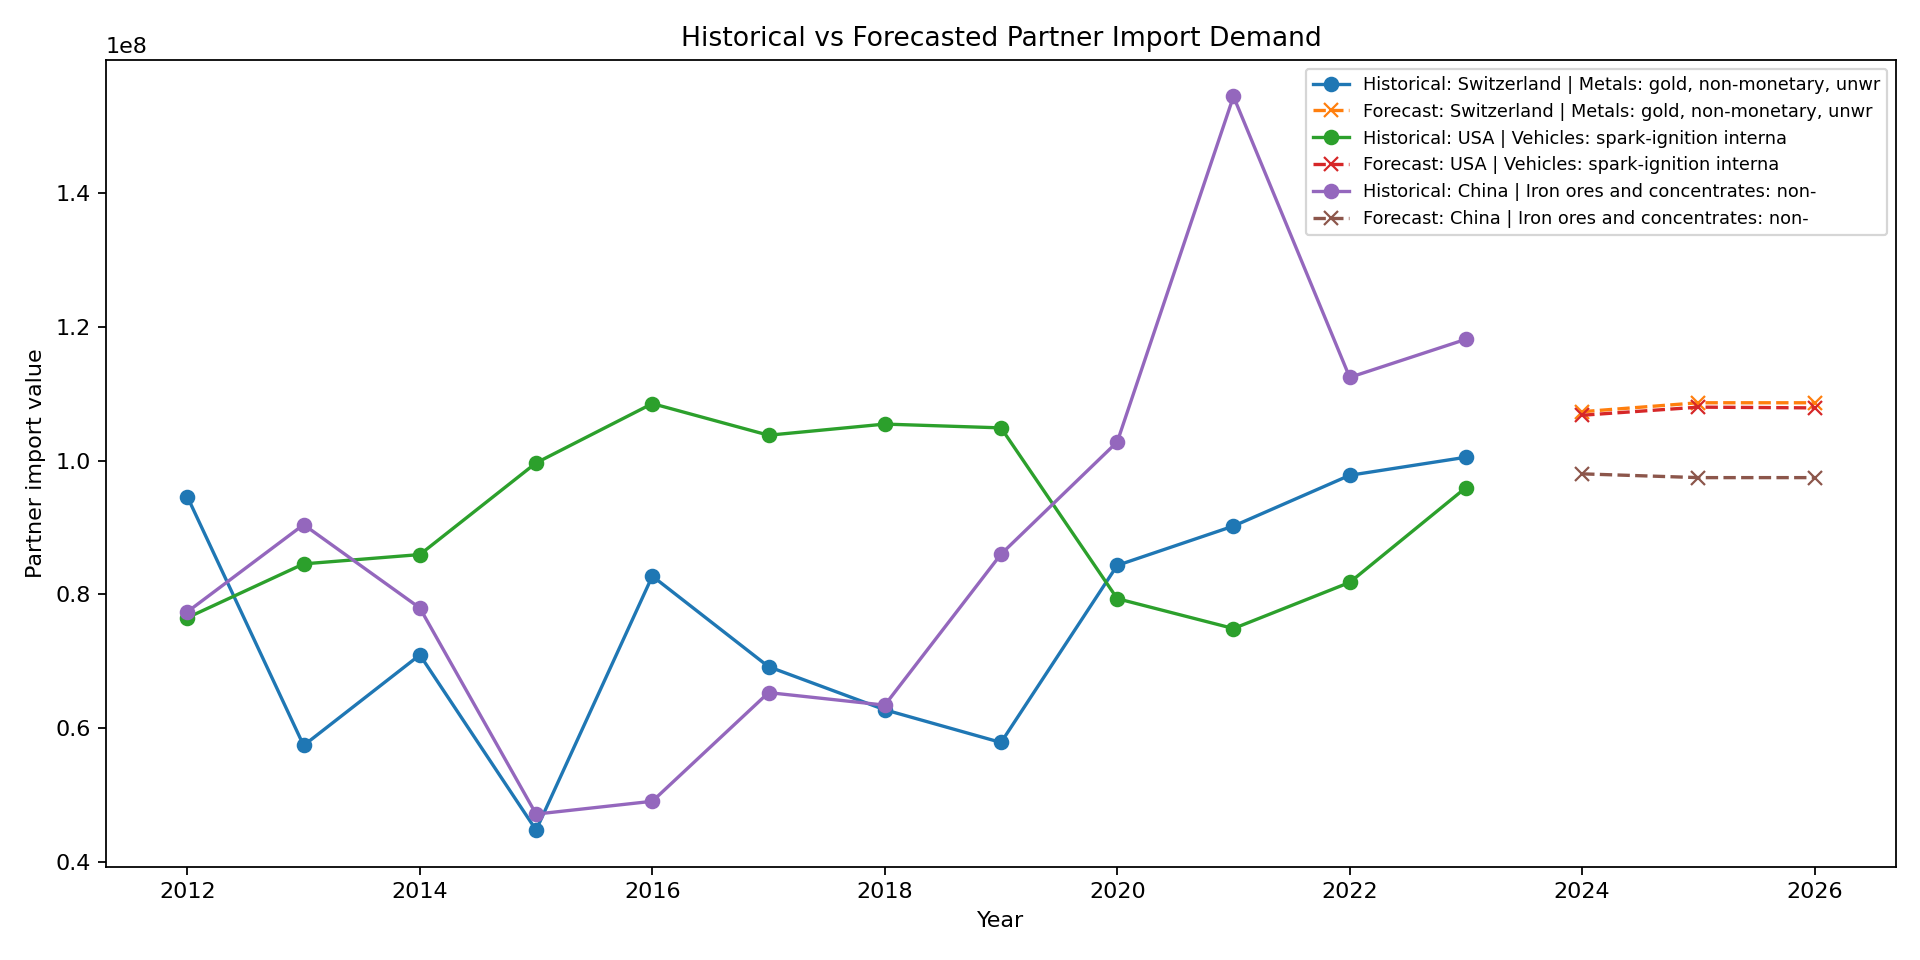

C:\Users\dey store\Documents\ml-project\machine-learning-project\data\forecast_outputs\plots\actual_vs_predicted_test_years.png


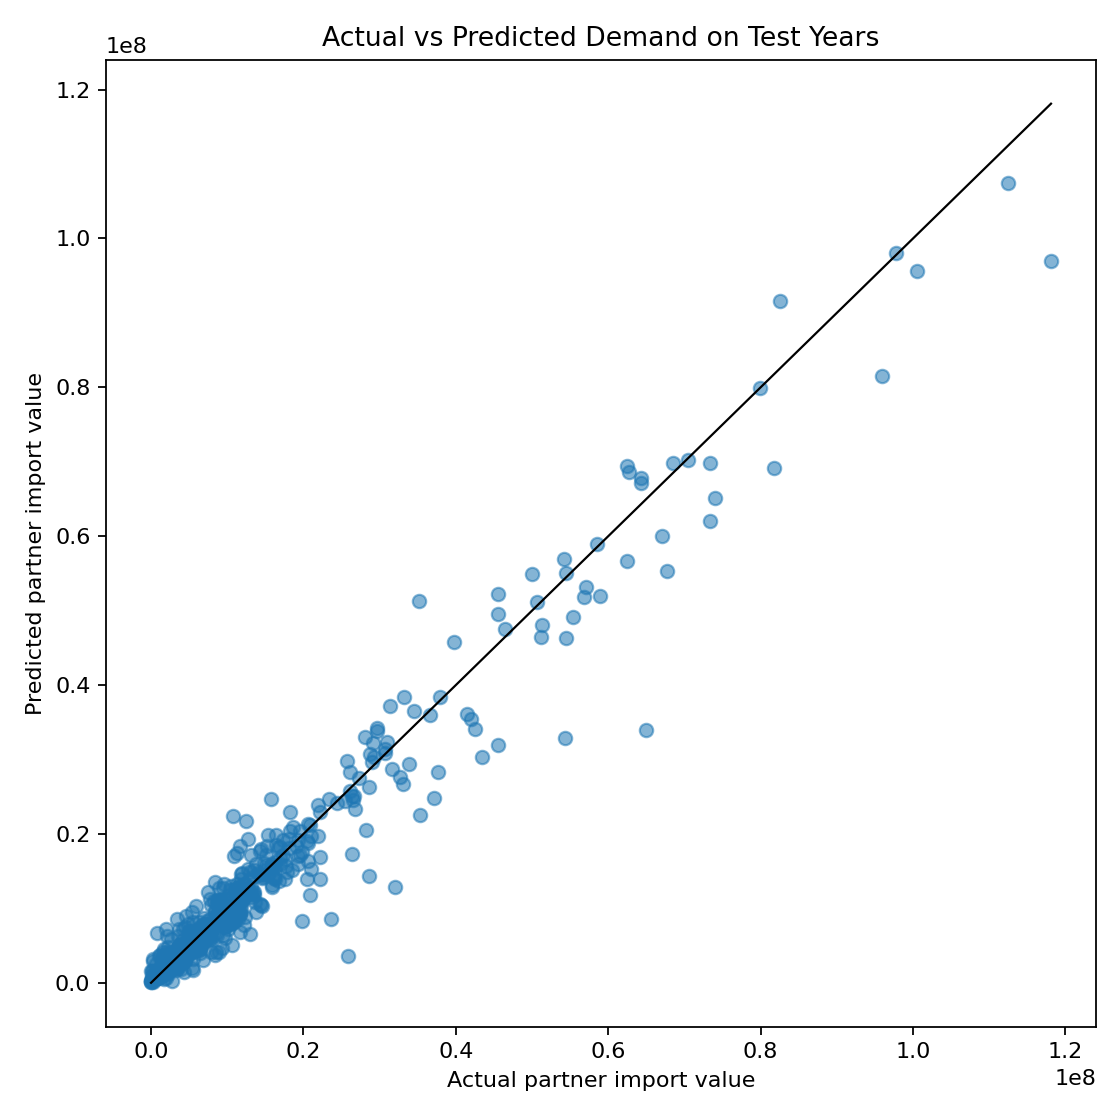

C:\Users\dey store\Documents\ml-project\machine-learning-project\data\forecast_outputs\plots\top_predicted_growth_countries.png


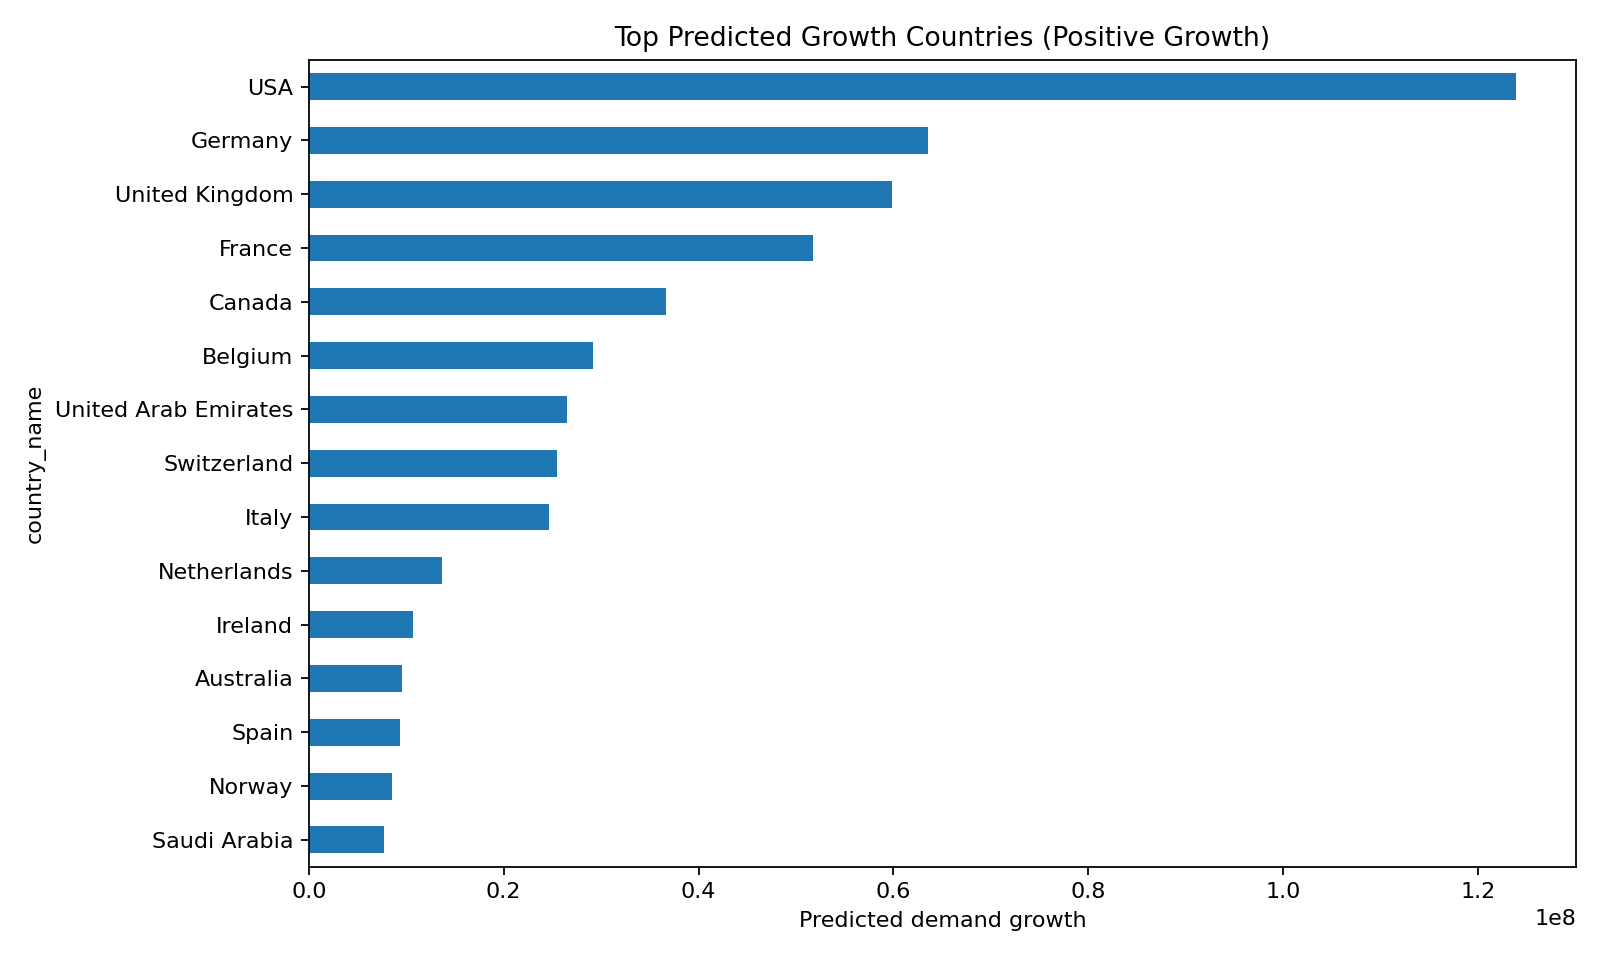

C:\Users\dey store\Documents\ml-project\machine-learning-project\data\forecast_outputs\plots\top_predicted_growth_products.png


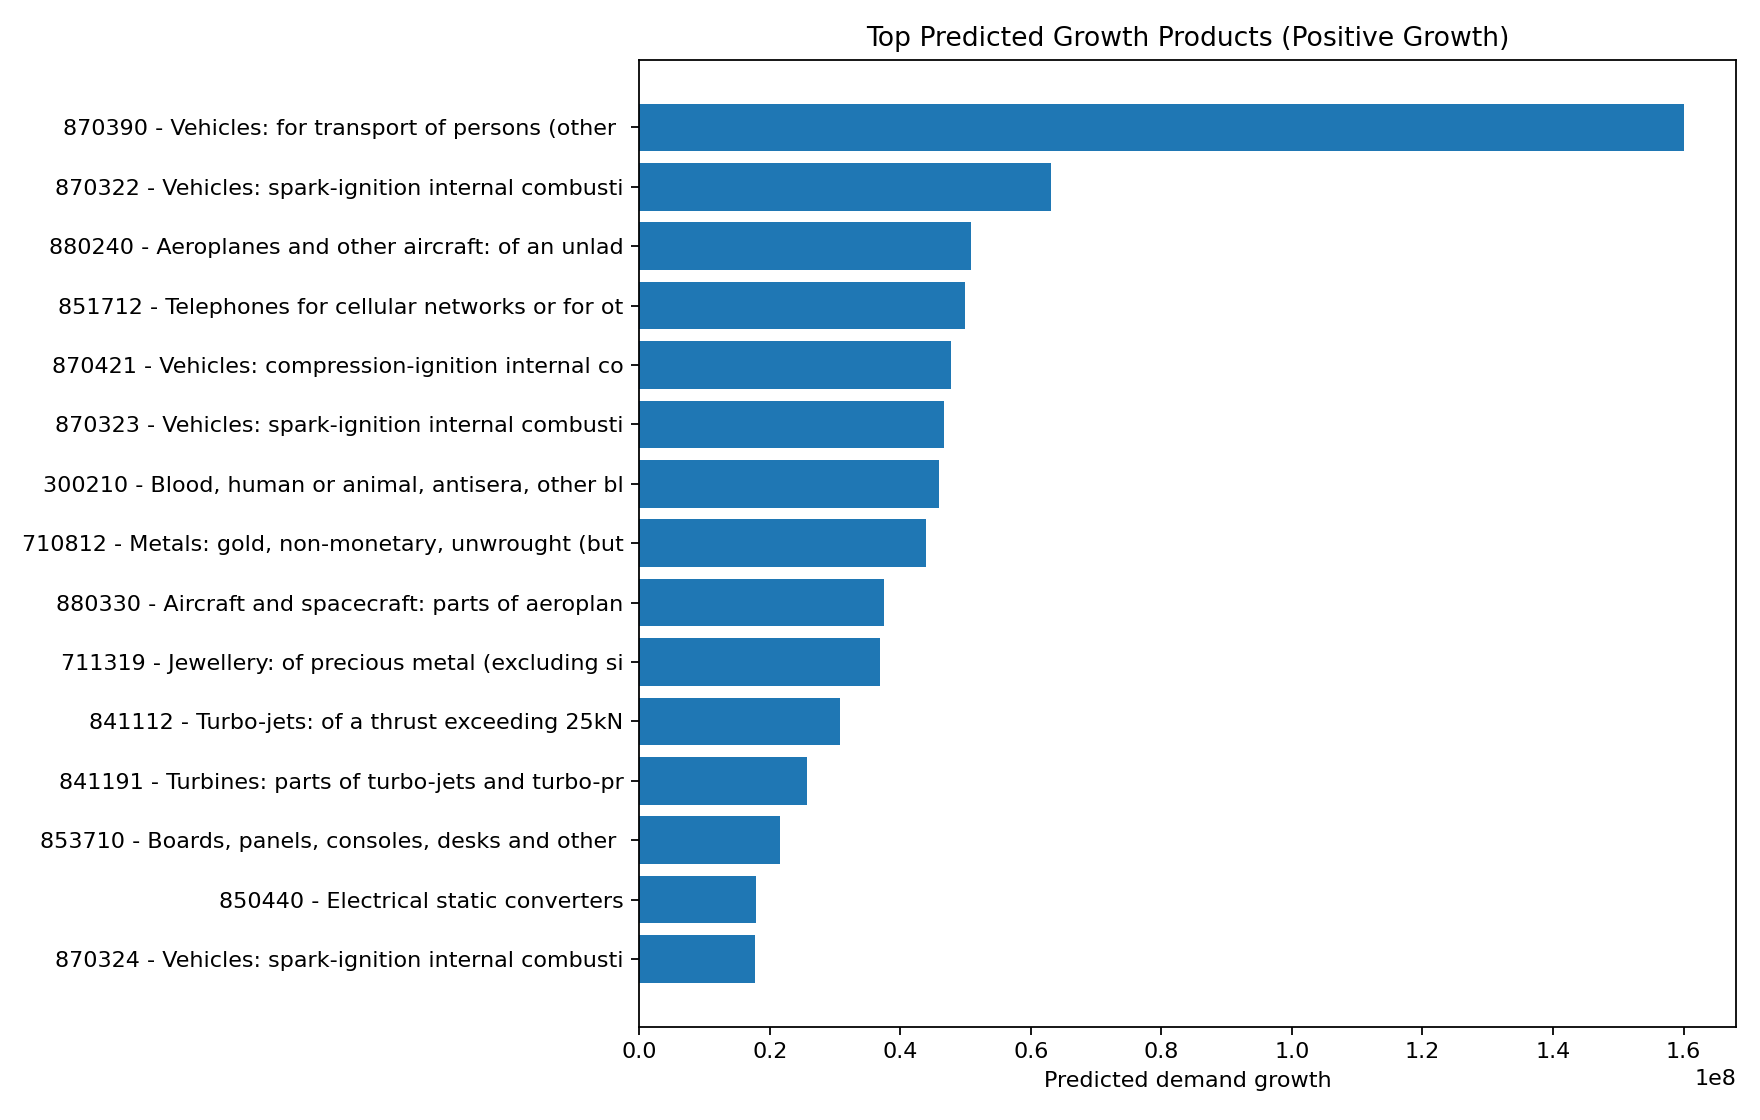

C:\Users\dey store\Documents\ml-project\machine-learning-project\data\forecast_outputs\plots\forecast_error_comparison_by_model.png


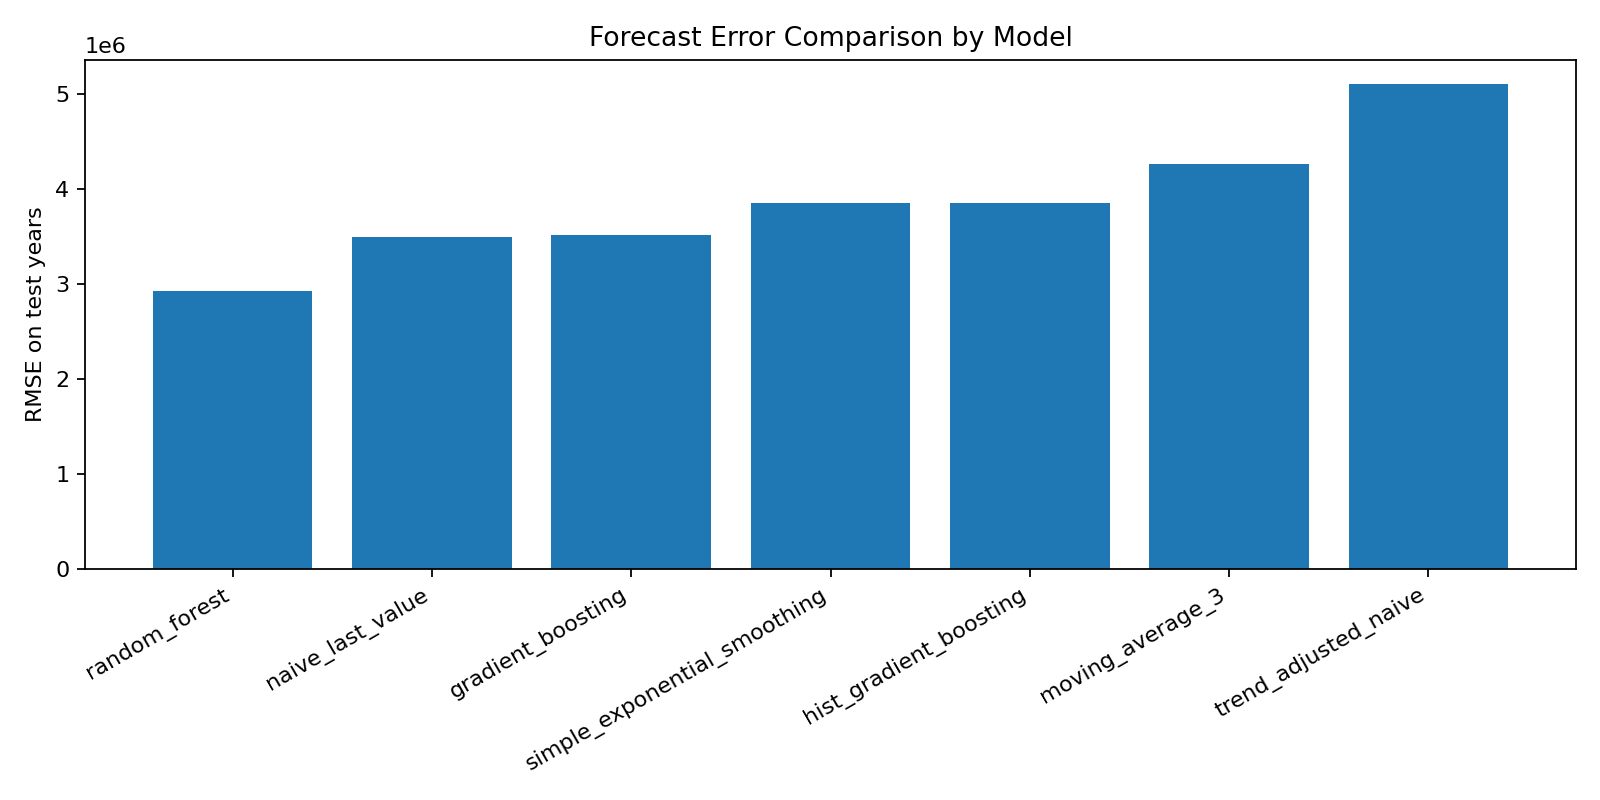

In [11]:
from IPython.display import Image, display

plot_files = [
    "historical_vs_forecasted_demand.png",
    "actual_vs_predicted_test_years.png",
    "top_predicted_growth_countries.png",
    "top_predicted_growth_products.png",
    "forecast_error_comparison_by_model.png",
]

for plot_file in plot_files:
    path = OUTPUT_DIR / "plots" / plot_file
    print(path)
    display(Image(filename=str(path)))

## Limitations

The annual panel is short, with only 12 historical years. Forecasts should therefore be interpreted as directional demand signals, not exact trade predictions. The default non-hydrocarbon filter is intentionally strict because the project focuses on diversification. Some products containing the word `oils` may be excluded even if they are not mineral fuels; this can be relaxed later if the group wants a broader non-hydrocarbon definition.

The preliminary forecast outputs are ready for dashboard integration, but the final opportunity ranking should still combine forecasts with opportunity labels, market penetration, RCA, and Algeria-specific export context.